# Homework <a class="anchor" id="section_homework"></a>

**HW 2/1**: <br>
Smart up our plotter to be able to customize the hard-coded layout setup inside the function. Add more custom feature that you would like to use.


**HW 2/2**: <br>
Upgrade the BSM call option pricer to be able to return the greeks as well, not just the price.


In [5]:
from typing import Union, List
import numpy as np
from scipy.stats import norm


def black_scholes_eur_call(
    r: float,
    T: float,
    S0: float,
    sigma: float,
    K: Union[float, List[float], np.ndarray],
):
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param 
    """
    #check conditions
    assert sigma > 0

    K_vec = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (np.log(S0 / K_vec) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_vec = d1_vec - sigma * np.sqrt(T)

    
    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)
    n_d1_vec = norm.pdf(d1_vec)  #sűrűségfüggvény ()

    #PRICE
    price = N_d1_vec*S0 - K_vec * np.exp((-1.0)*r*T) * N_d2_vec

    #GREEKS
    delta = N_d1_vec

    gamma = n_d1_vec / (S0 * sigma * np.sqrt(T))

    vega = S0 * n_d1_vec * np.sqrt(T)

    theta = (
        -S0 * n_d1_vec * sigma / (2 * np.sqrt(T))
        - r * K_vec * np.exp(-r * T) * N_d2_vec
    )

    rho = K_vec * T * np.exp(-r * T) * N_d2_vec

    # dictionary a return
    return {
        "price": price,
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta,
        "rho": rho,
    }

In [5]:
call=black_scholes_eur_call(r=0.05, T=1, S0=20.0, sigma=0.3, K=10)
print("price: ", call["price"])
print("delta: ", call["delta"])

price:  10.49652216075794
delta:  0.9956949235179967


Greekek plotolása a spot függvényében call esetén

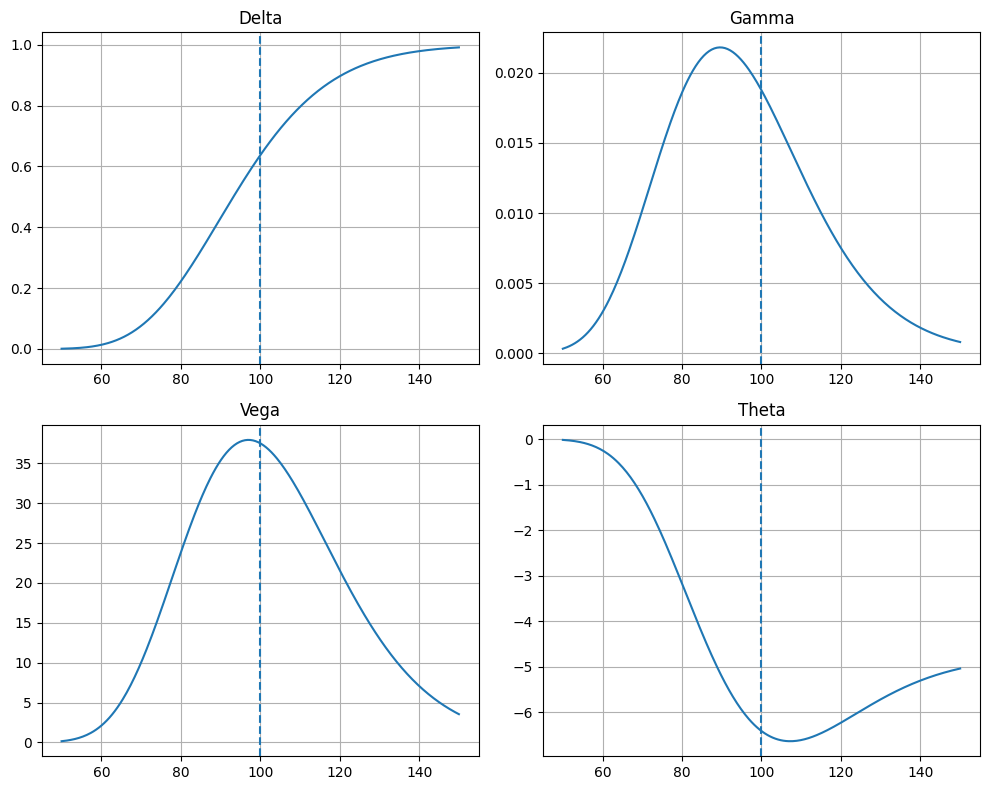

In [21]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.05
T = 1.0
K = 100
sigma = 0.2

S0_grid = np.linspace(50, 150, 300)

delta_vals = []
gamma_vals = []
vega_vals = []
theta_vals = []

for S0 in S0_grid:
    res = black_scholes_eur_call(r, T, S0, sigma, K)
    delta_vals.append(float(res["delta"]))
    gamma_vals.append(float(res["gamma"]))
    vega_vals.append(float(res["vega"]))
    theta_vals.append(float(res["theta"]))


fig, axs = plt.subplots(2,2, figsize=(10,8))

axs[0,0].plot(S0_grid, delta_vals)
axs[0,0].set_title("Delta")

axs[0,1].plot(S0_grid, gamma_vals)
axs[0,1].set_title("Gamma")

axs[1,0].plot(S0_grid, vega_vals)
axs[1,0].set_title("Vega")

axs[1,1].plot(S0_grid, theta_vals)
axs[1,1].set_title("Theta")

for ax in axs.flat:
    ax.axvline(K, linestyle="--")
    ax.grid(True)

plt.tight_layout()
plt.show()

**HW 2/3**: <br>
Implement the BSM pricer for Eluropean put option.


In [19]:
def black_scholes_eur_put(
    r: float,
    T: float,
    S0: float,
    sigma: float,
    K: Union[float, List[float], np.ndarray],
):
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param 
    """
    #check conditions
    assert sigma > 0

    K_vec = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (np.log(S0 / K_vec) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_vec = d1_vec - sigma * np.sqrt(T)

    
    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)
    n_d1_vec = norm.pdf(d1_vec)  #sűrűségfüggvény ()

    #PRICE
    price = K_vec * np.exp(-r*T) * norm.cdf(-d2_vec) - S0 * norm.cdf(-d1_vec)

    #GREEKS
    delta = norm.cdf(d1_vec) - 1

    gamma = n_d1_vec / (S0 * sigma * np.sqrt(T))

    vega = S0 * n_d1_vec * np.sqrt(T)

    theta = (
        -S0 * n_d1_vec * sigma / (2 * np.sqrt(T))
        + r * K_vec * np.exp(-r*T) * norm.cdf(-d2_vec)
    )

    rho = -K_vec * T * np.exp(-r*T) * norm.cdf(-d2_vec)

    # dictionary a return
    return {
        "price": price,
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta,
        "rho": rho,
    }

In [7]:
put=black_scholes_eur_put(r=0.05, T=1, S0=20.0, sigma=0.3, K=10)
put["price"]

0.008816405765081262

Greekek plotolása a spot függvényében put esetén

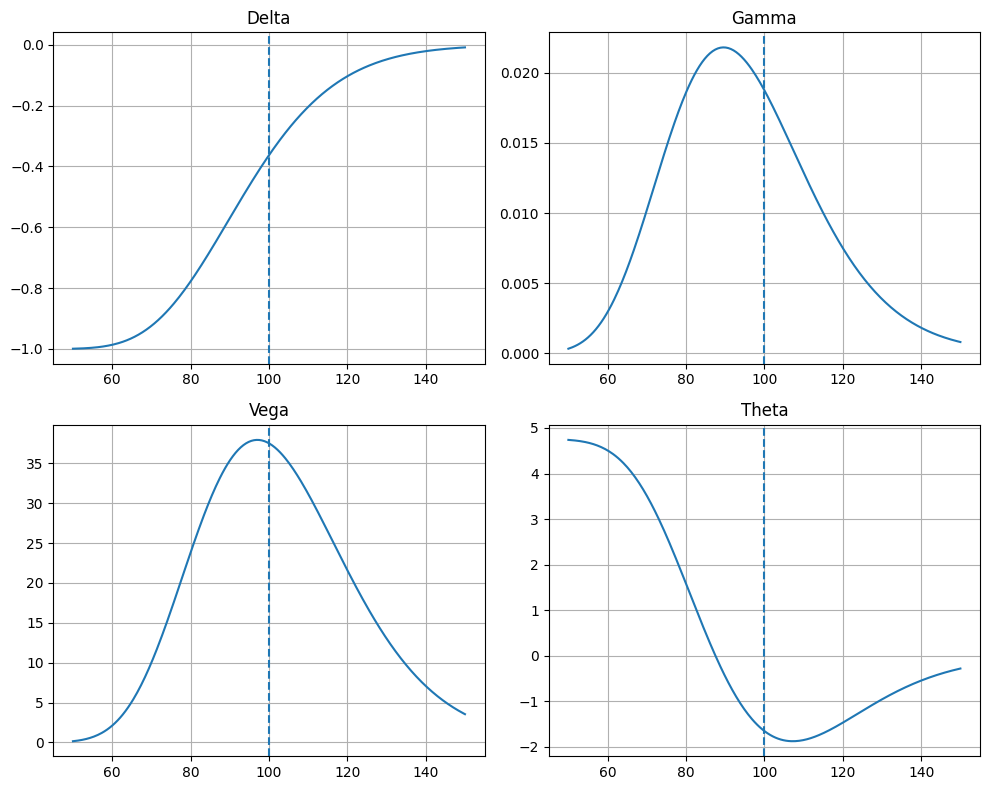

In [20]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.05
T = 1.0
K = 100
sigma = 0.2

S0_grid = np.linspace(50, 150, 300)

delta_vals = []
gamma_vals = []
vega_vals = []
theta_vals = []

for S0 in S0_grid:
    res = black_scholes_eur_put(r, T, S0, sigma, K)
    delta_vals.append(float(res["delta"]))
    gamma_vals.append(float(res["gamma"]))
    vega_vals.append(float(res["vega"]))
    theta_vals.append(float(res["theta"]))


fig, axs = plt.subplots(2,2, figsize=(10,8))

axs[0,0].plot(S0_grid, delta_vals)
axs[0,0].set_title("Delta")

axs[0,1].plot(S0_grid, gamma_vals)
axs[0,1].set_title("Gamma")

axs[1,0].plot(S0_grid, vega_vals)
axs[1,0].set_title("Vega")

axs[1,1].plot(S0_grid, theta_vals)
axs[1,1].set_title("Theta")

for ax in axs.flat:
    ax.axvline(K, linestyle="--")
    ax.grid(True)

plt.tight_layout()
plt.show()

**HW 2/4**: <br>
With the call and put pricer, check if Put-Call parity holds in practice.

\begin{equation}
c_t - p_t = S_t - K\cdot e^{-r\cdot(T-t)}
\end{equation}

In [8]:
r=0.05
T=1
S0=100
sigma=0.3
K=105

call=black_scholes_eur_call(r,T,S0,sigma,K)
put=black_scholes_eur_put(r,T,S0,sigma,K)
call["price"]-put["price"]-(S0-K*np.exp(-r*T))  #csak kerekítési hiba miatt nem nulla

-1.4210854715202004e-14

Ha 10000 esetre véletlen paraméterekkel futtatom, akkor is igazából csak kerekítési hiba lesz, tehát teljesül a put cal paritás

In [8]:
import random

hiba = 0
r_min, r_max = 0.02, 0.15
T_min, T_max = 0.2, 3
S0_min, S0_max = 10, 200
sigma_min, sigma_max = 0.05, 0.8
K_min, K_max = 10, 200


M = 10000

for i in range(M):
    #random értékek
    r = random.uniform(r_min, r_max)
    T = random.uniform(T_min, T_max)
    S0 = random.uniform(S0_min, S0_max)
    sigma = random.uniform(sigma_min, sigma_max)
    K = random.uniform(K_min, K_max)

    #put call paritás
    call = black_scholes_eur_call(r, T, S0, sigma, K)
    put = black_scholes_eur_put(r, T, S0, sigma, K)
    hiba = hiba + abs(call["price"] - put["price"]-(S0 - K * np.exp(-r * T)))
    
hiba

array([6.55759891e-11])